# Evaluate DBNet on Colab

Loads the checkpoint saved by `train_model.ipynb` (`MyDrive/document-processing/checkpoints/dbnet_best.pt`) and checks it on the test receipts. A GPU runtime is faster but not required.

In [1]:
!nvidia-smi

Thu Sep 24 16:20:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/dataset_receipt'
CKPT_DIR = '/content/drive/MyDrive/document-processing/checkpoints'  # on Drive so it survives disconnects

Mounted at /content/drive


In [3]:
import os

# For a private repo, add a GITHUB_TOKEN secret in the Colab sidebar (key icon). Never hardcode it here.
try:
    from google.colab import userdata
    token = userdata.get('GITHUB_TOKEN')
except Exception:
    token = None

auth = f"{token}@" if token else ""
REPO_URL = f"https://{auth}github.com/alexisvannson/document-processing.git"
REPO_DIR = '/content/document-processing'
BRANCH = 'main'

if os.path.isdir(REPO_DIR):
    !git -C {REPO_DIR} pull -q
else:
    !git clone -q -b {BRANCH} {REPO_URL} {REPO_DIR}
%cd {REPO_DIR}

/content/document-processing


In [4]:
# Colab already ships torch/torchvision with CUDA; this installs the rest.
!pip install -q -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 972.1/972.1 kB 51.9 MB/s eta 0:00:00


In [5]:
# Copy the dataset to local disk: reading hundreds of images from Drive every epoch is very slow.
!rsync -a --info=progress2 {DRIVE_DIR}/ /content/dataset_receipt/
!ls /content/dataset_receipt/images | wc -l

    476,898,079 100%   27.46MB/s    0:00:16 (xfr#202, to-chk=0/204)
200


## Evaluate the DBNet checkpoint

Loads `dbnet_best.pt` from Drive and re-runs the training metric (precision / recall / F1 at IoU ≥ 0.5) on the held-out test receipts (same seed as training, so the same split). Run the setup cells above first.

In [ ]:
import os
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

from dataset import get_dataloaders, transform
from getDBbboxes import extract_bounding_boxes
from models.DBNET import DBNet
from train_dbnet import evaluate, match_boxes

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DBNet().to(device)
model.load_state_dict(torch.load(f'{CKPT_DIR}/dbnet_best.pt', map_location=device))
model.eval()

_, _, test_loader = get_dataloaders('/content/dataset_receipt/metadata.pkl', '/content/dataset_receipt/images',
                                  batch_size=1, num_workers=2, seed=42)
test_loss, precision, recall, f1 = evaluate(model, test_loader, device)
print(f'Test receipts: {len(test_loader.dataset)} | precision {precision:.3f} | recall {recall:.3f} | F1 {f1:.3f}')

In [ ]:
ds = test_loader.dataset
MEAN, STD = np.array([0.485, 0.456, 0.406]), np.array([0.229, 0.224, 0.225])

@torch.no_grad()
def predict(idx):
    """Image (as fed to the model), probability map, predicted and ground-truth boxes for test receipt idx."""
    image, *_ = ds[idx]
    prob = model(image[None].to(device))[0, 0].cpu().numpy()
    row = ds.df.iloc[idx]
    h, w = cv2.imread(os.path.join(ds.img_dir, row.file_name)).shape[:2]
    s = 1280 / max(h, w)  # same rescaling as evaluate()
    gt = [[[b[f'x{k}'] * s, b[f'y{k}'] * s] for k in range(1, 5)] for b in row.bboxes]
    img = ((image.permute(1, 2, 0).numpy() * STD + MEAN).clip(0, 1) * 255).astype(np.uint8)
    return img, prob, extract_bounding_boxes(prob), gt

# Per-receipt F1, to see where the model struggles
scores = []
for i in range(len(ds)):
    _, _, pred, gt = predict(i)
    tp = match_boxes(pred, gt)
    p, r = tp / max(len(pred), 1), tp / max(len(gt), 1)
    scores.append(2 * p * r / max(p + r, 1e-6))
scores = np.array(scores)
print(f'Per-receipt F1: mean {scores.mean():.3f} | median {np.median(scores):.3f} | min {scores.min():.3f}')
print('Receipts below 0.8:', int((scores < 0.8).sum()))

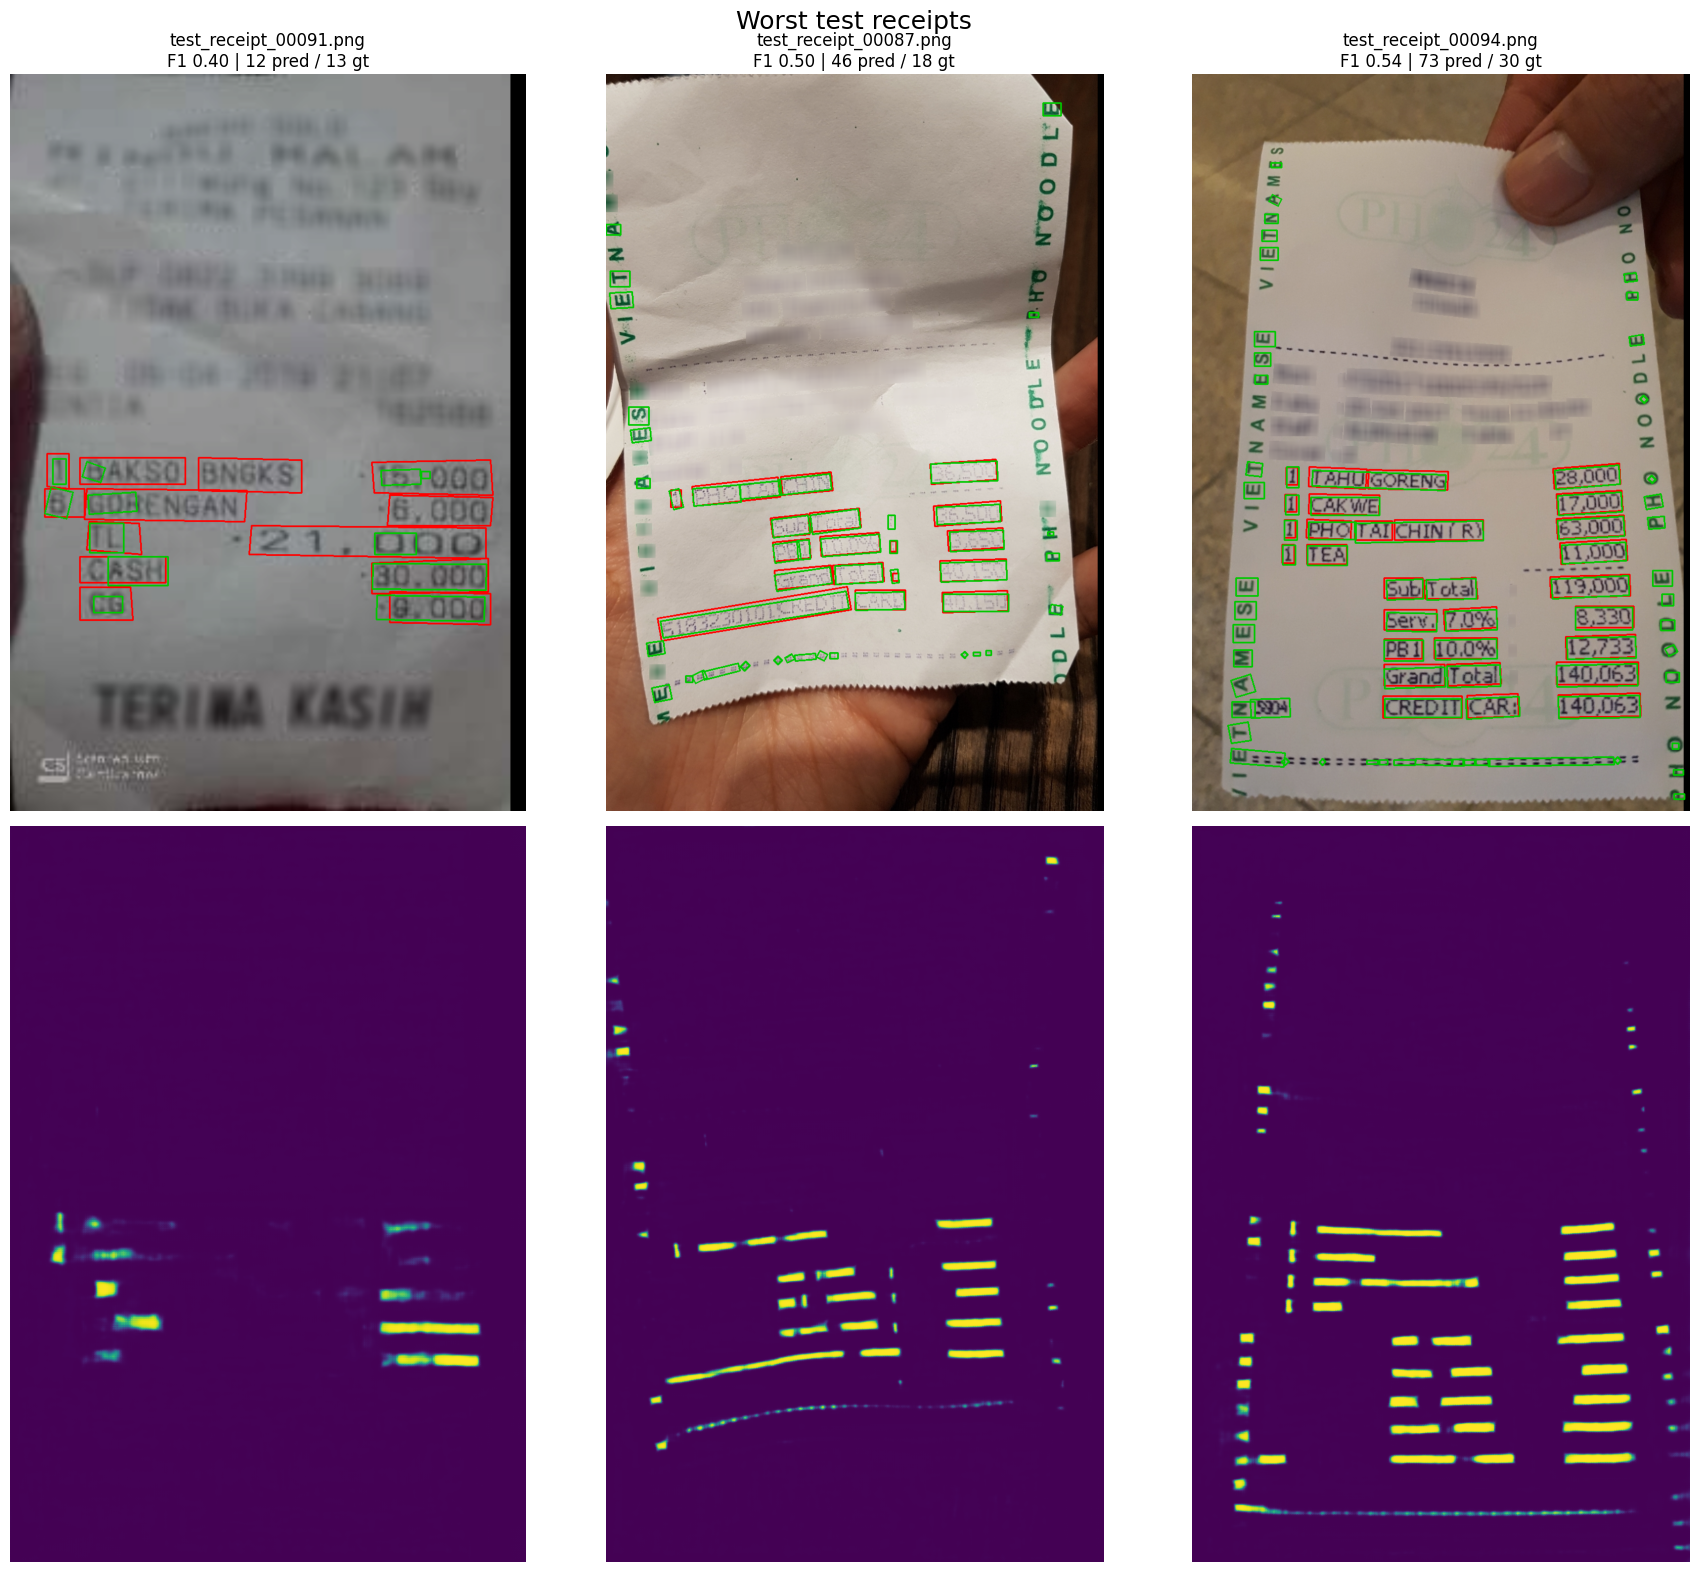

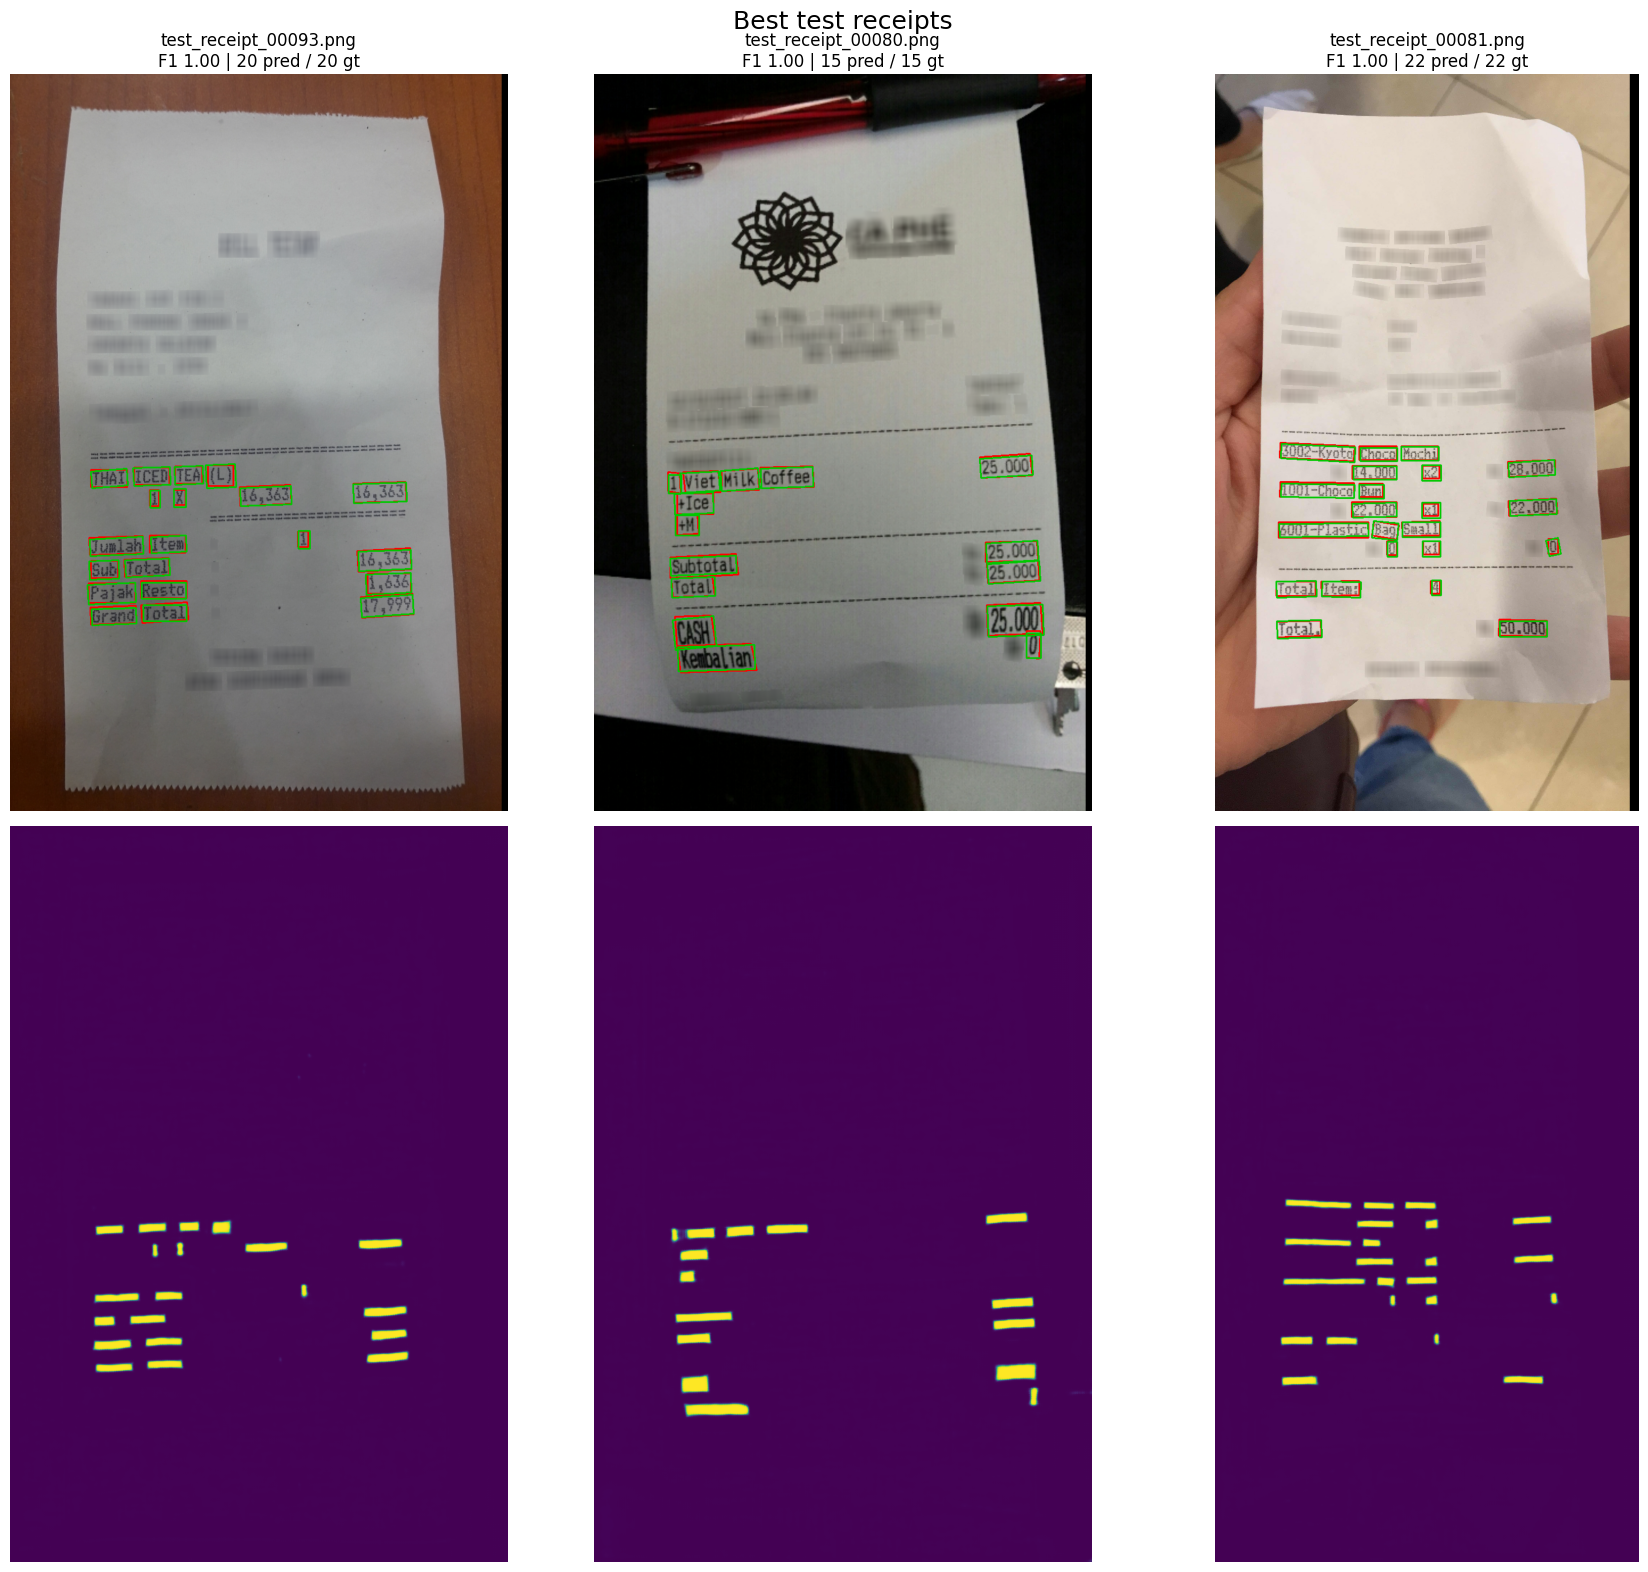

In [8]:
def show(indices, title):
    """Ground truth in red, predictions in green, probability map next to each."""
    fig, axes = plt.subplots(2, len(indices), figsize=(6 * len(indices), 16))
    for col, idx in enumerate(indices):
        img, prob, pred, gt = predict(idx)
        vis = img.copy()
        cv2.polylines(vis, [np.int32(g) for g in gt], True, (255, 0, 0), 2)
        cv2.polylines(vis, [np.int32(b) for b in pred], True, (0, 200, 0), 2)
        axes[0, col].imshow(vis)
        axes[0, col].set_title(f'{ds.df.iloc[idx].file_name}\nF1 {scores[idx]:.2f} | {len(pred)} pred / {len(gt)} gt')
        axes[1, col].imshow(prob, cmap='viridis', vmin=0, vmax=1)
        for ax in axes[:, col]:
            ax.axis('off')
    fig.suptitle(title, fontsize=18)
    plt.tight_layout()
    plt.show()

order = np.argsort(scores)
show(order[:3], 'Worst test receipts')
show(order[-3:], 'Best test receipts')

### Detect text on your own image

Upload any image (e.g. a medical report) with the file browser on the left and set `IMAGE_PATH`.

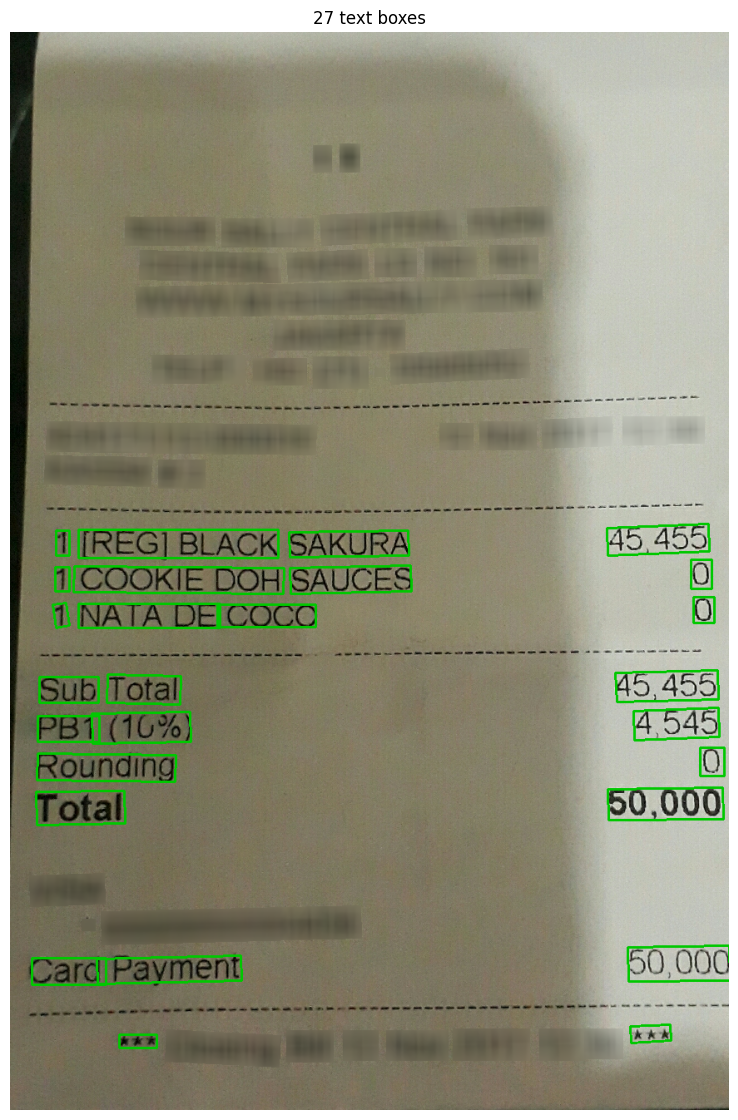

In [9]:
IMAGE_PATH = '/content/dataset_receipt/images/test_receipt_00008.png'

@torch.no_grad()
def detect(path):
    """Boxes in the original image's coordinates."""
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    x = transform(image=img)['image'][None].to(device)  # longest side -> 1280, padded bottom/right
    prob = model(x)[0, 0].cpu().numpy()
    s = 1280 / max(img.shape[:2])
    return img, [b / s for b in extract_bounding_boxes(prob)]

img, boxes = detect(IMAGE_PATH)
vis = img.copy()
cv2.polylines(vis, [np.int32(b) for b in boxes], True, (0, 200, 0), max(2, max(img.shape[:2]) // 500))
plt.figure(figsize=(10, 14))
plt.imshow(vis)
plt.title(f'{len(boxes)} text boxes')
plt.axis('off')
plt.show()

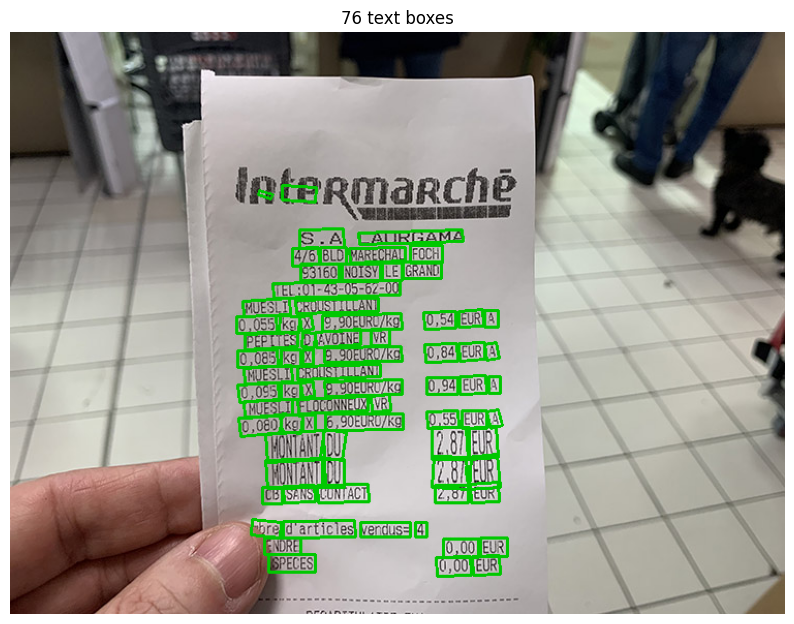

In [10]:
IMAGE_PATH = "/content/IMG_0758-TEST.jpg"

img, boxes = detect(IMAGE_PATH)
vis = img.copy()
cv2.polylines(vis, [np.int32(b) for b in boxes], True, (0, 200, 0), max(2, max(img.shape[:2]) // 500))
plt.figure(figsize=(10, 14))
plt.imshow(vis)
plt.title(f'{len(boxes)} text boxes')
plt.axis('off')
plt.show()

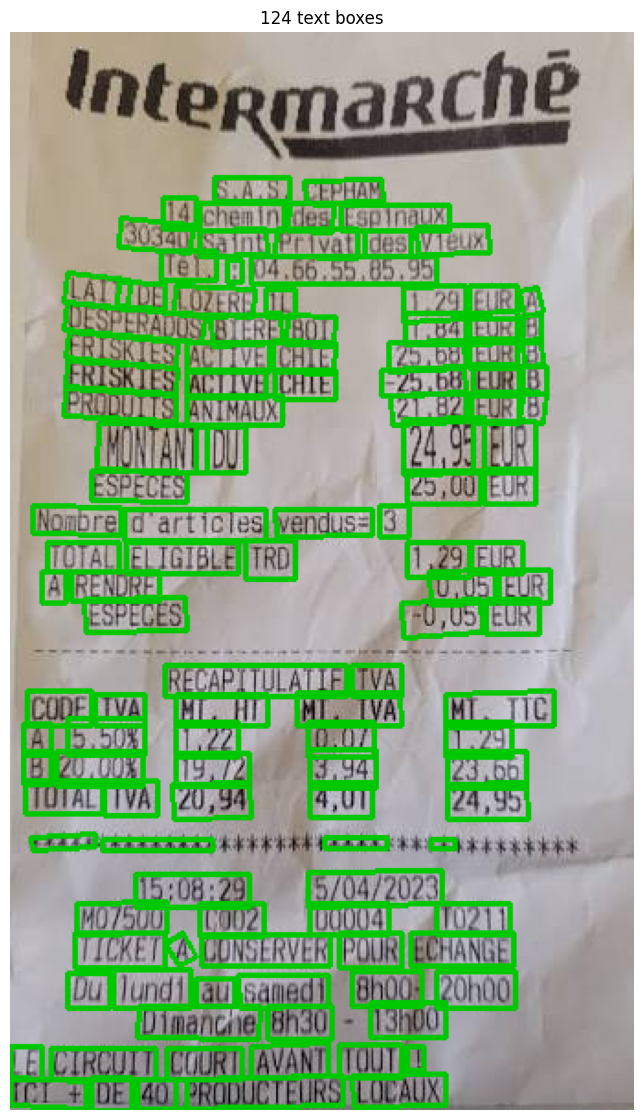

In [11]:
IMAGE_PATH = "/content/images-test2.jpeg"

img, boxes = detect(IMAGE_PATH)
vis = img.copy()
cv2.polylines(vis, [np.int32(b) for b in boxes], True, (0, 200, 0), max(2, max(img.shape[:2]) // 500))
plt.figure(figsize=(10, 14))
plt.imshow(vis)
plt.title(f'{len(boxes)} text boxes')
plt.axis('off')
plt.show()

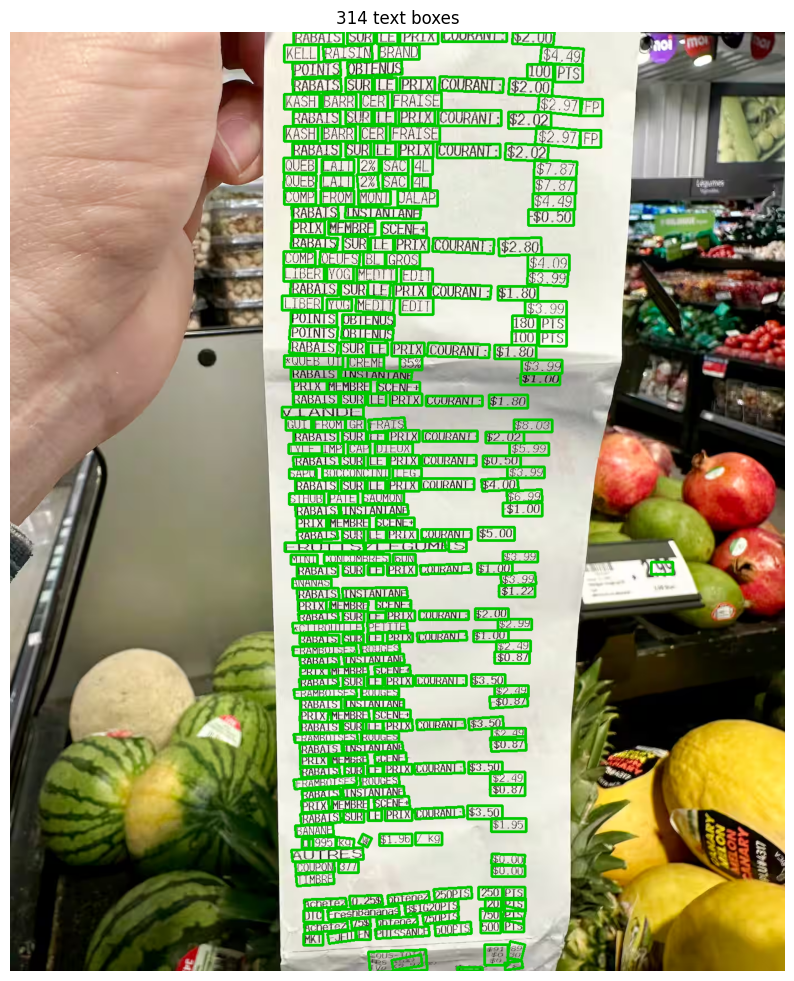

In [12]:
IMAGE_PATH = "/content/test-3.jpeg"

img, boxes = detect(IMAGE_PATH)
vis = img.copy()
cv2.polylines(vis, [np.int32(b) for b in boxes], True, (0, 200, 0), max(2, max(img.shape[:2]) // 500))
plt.figure(figsize=(10, 14))
plt.imshow(vis)
plt.title(f'{len(boxes)} text boxes')
plt.axis('off')
plt.show()